# VDL Mini-Challenge: Image Captioning mit Attention

Dieses bereinigte Notebook enthält die finale, lineare Experimentstruktur für die Mini-Challenge. Die frühere Arbeitsversion mit Debug- und Zwischenzellen bleibt separat erhalten.

## 1 Ziel und Vorgehen

Ziel ist Image Captioning auf Flickr8k: Zu jedem Bild soll automatisch eine kurze Caption generiert werden. Verglichen werden zwei Modellvarianten:

1. **CNN-LSTM-Baseline ohne Attention**: ResNet18 erzeugt einen globalen Bildvektor, ein LSTM generiert die Caption.
2. **CNN-LSTM mit Soft-Attention**: ResNet18 erzeugt eine räumliche Feature-Map, der Decoder lernt pro Token eine Gewichtung über Bildregionen.

Für beide Modelle wird Greedy-Decoding verwendet. Transformer-Decoder und Beam Search werden bewusst gestrichen, damit der Vergleich fokussiert und fair bleibt. Attention passt zur Aufgabenstellung, weil Image Captioning nicht nur Sprache modelliert, sondern Bildinhalte lokalisieren und beschreiben muss. Zusätzlich liefert Attention Heatmaps als Interpretierbarkeitsartefakte; diese sind hilfreich, aber kein alleiniger Qualitätsbeweis.

## 2 Setup

Die Konstanten sind bewusst einfach gehalten. Für den ersten fairen Vergleich bleiben Encoder, Batch Size, Embedding/Hidden-Dimensionen, Learning Rate und Decoding-Strategie gleich.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
from typing import Any, Optional, Union
import os
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from IPython.display import display

try:
    import lightning as L
except ImportError:
    import pytorch_lightning as L

try:
    from lightning.pytorch.callbacks import Callback, ModelCheckpoint
except ImportError:
    from pytorch_lightning.callbacks import Callback, ModelCheckpoint

from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu

import sys
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from vdl_helpers import (
    configure_torch_for_apple_silicon,
    count_parameters,
    get_best_device,
    load_json,
    plot_attention_overlay,
    plot_training_curves,
    save_json,
    set_seed,
)

# remark: keep matplotlib and torch model caches inside the project where possible.
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))
os.environ.setdefault("TORCH_HOME", str(PROJECT_ROOT / "outputs" / "torch_home"))

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # remark: notebook/MPS-friendly default on macOS; increase locally if desired.
MIN_FREQ = 5  # remark: keeps the vocabulary smaller and reduces rare-word noise.
MAX_CAPTION_LEN = 40
MAX_EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 0.0
EMBED_DIM = 256
HIDDEN_DIM = 512
ATTENTION_DIM = 256
DECODER_DROPOUT = 0.1
ENCODER_NAME = "resnet18"
FREEZE_ENCODER = True  # remark: resource-friendly and fair for the first comparison.
PRETRAINED_ENCODER = True
MAX_DECODE_LEN = 25

RUN_OVERFIT_TESTS = False  # remark: set True to run the 100-epoch fixed mini-batch checks.
RUN_FULL_TRAINING = False  # remark: default for hand-in; loads checkpoints if available.
OVERFIT_EPOCHS = 100

set_seed(SEED)
configure_torch_for_apple_silicon()
DEVICE = get_best_device(prefer_mps=True)  # remark: use MPS if available, otherwise fall back to CPU.
print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)

Project root: /Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC
Device: mps


## 3 Daten und kurze EDA

Flickr8k enthält mehrere Captions pro Bild. Splits werden aus offiziellen Split-Dateien geladen, falls vorhanden; sonst werden sie reproduzierbar auf Bild-Ebene erstellt. Die EDA bleibt knapp: Umfang, Split-Verteilung, Bildgrössen und Caption-Längen.

In [2]:
def find_flickr8k_paths(data_root: Path) -> dict[str, Optional[Path]]:
    """Find common Flickr8k image, caption, and split files below data_root."""
    data_root = Path(data_root)
    image_dir_candidates = [
        data_root / "Flickr8k" / "Images",
        data_root / "Flickr8k" / "images",
        data_root / "Flicker8k_Dataset",
        data_root / "Flickr8k_Dataset",
        data_root / "Flickr_8k_Dataset",
        data_root / "Images",
    ]
    caption_candidates = [
        data_root / "Flickr8k" / "captions.txt",
        data_root / "captions.txt",
        data_root / "Flickr8k.token.txt",
        data_root / "Flickr8k" / "Flickr8k.token.txt",
        data_root / "Flickr8k_text" / "Flickr8k.token.txt",
    ]
    image_dir = next((p for p in image_dir_candidates if p.exists() and p.is_dir()), None)
    captions_file = next((p for p in caption_candidates if p.exists() and p.is_file()), None)

    split_names = {
        "train": ["Flickr_8k.trainImages.txt", "Flickr8k.trainImages.txt", "trainImages.txt"],
        "val": ["Flickr_8k.devImages.txt", "Flickr8k.devImages.txt", "devImages.txt", "valImages.txt"],
        "test": ["Flickr_8k.testImages.txt", "Flickr8k.testImages.txt", "testImages.txt"],
    }
    split_files = {}
    for split, names in split_names.items():
        candidates = [data_root / name for name in names]
        candidates += [data_root / "Flickr8k" / name for name in names]
        candidates += [data_root / "Flickr8k_text" / name for name in names]
        split_files[split] = next((p for p in candidates if p.exists() and p.is_file()), None)

    if image_dir is None or captions_file is None:
        raise FileNotFoundError("Flickr8k image directory or captions file not found below data/.")
    return {"image_dir": image_dir, "captions_file": captions_file, **split_files}


def read_caption_file(captions_file: Path) -> pd.DataFrame:
    """Read Flickr8k captions from either captions.txt CSV or old token format."""
    captions_file = Path(captions_file)
    try:
        csv_df = pd.read_csv(captions_file)
        csv_df = csv_df.rename(columns={c: c.strip().lower() for c in csv_df.columns})
        if {"image", "caption"}.issubset(csv_df.columns):
            df = csv_df[["image", "caption"]].copy()
            df["image_id"] = df["image"].astype(str).str.strip()
            df["caption"] = df["caption"].astype(str).str.strip()
            return df[["image_id", "caption"]].dropna().reset_index(drop=True)
    except Exception:
        pass

    rows = []
    for line in captions_file.read_text(encoding="utf-8", errors="replace").splitlines():
        if "\t" not in line:
            continue
        image_token, caption = line.split("\t", 1)
        rows.append({"image_id": image_token.split("#", 1)[0].strip(), "caption": caption.strip()})
    if not rows:
        raise ValueError(f"Could not parse captions from {captions_file}")
    return pd.DataFrame(rows)


def read_split_file(path: Optional[Path]) -> Optional[set[str]]:
    if path is None:
        return None
    return {line.strip() for line in Path(path).read_text(encoding="utf-8").splitlines() if line.strip()}


def assign_splits(image_ids: list[str], paths: dict[str, Optional[Path]]) -> dict[str, str]:
    official = {split: read_split_file(paths.get(split)) for split in ["train", "val", "test"]}
    if all(official.values()):
        return {image_id: split for split, ids in official.items() for image_id in (ids or [])}

    train_ids, temp_ids = train_test_split(sorted(image_ids), test_size=0.20, random_state=SEED, shuffle=True)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED, shuffle=True)
    return {**{i: "train" for i in train_ids}, **{i: "val" for i in val_ids}, **{i: "test" for i in test_ids}}


def build_annotations(paths: dict[str, Optional[Path]]) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    captions = read_caption_file(Path(paths["captions_file"]))
    image_dir = Path(paths["image_dir"])
    captions["image_path"] = captions["image_id"].map(lambda name: image_dir / name)
    missing = captions.loc[~captions["image_path"].map(lambda p: Path(p).exists()), "image_id"].drop_duplicates().tolist()
    if missing:
        raise FileNotFoundError(f"Missing {len(missing)} images, e.g. {missing[:5]}")
    split_map = assign_splits(captions["image_id"].drop_duplicates().tolist(), paths)
    captions["split"] = captions["image_id"].map(split_map).fillna("unknown")
    captions = captions[["image_id", "image_path", "caption", "split"]].reset_index(drop=True)
    reference_captions = captions.groupby("image_id")["caption"].apply(list).to_dict()
    return captions, reference_captions


paths = find_flickr8k_paths(PROJECT_ROOT / "data")
annotations_df, reference_captions = build_annotations(paths)

split_summary = annotations_df.groupby("split").agg(images=("image_id", "nunique"), captions=("caption", "count"))
display(split_summary)
print("Unique images:", annotations_df["image_id"].nunique())
print("Captions:", len(annotations_df))

,images,captions
split,,
test,810,4050
train,6472,32360
val,809,4045


Unique images: 8091
Captions: 40455


In [3]:
def sample_image_sizes(df: pd.DataFrame, max_images: int = 500) -> pd.DataFrame:
    # remark: sample image sizes for a quick data-quality check without excessive I/O.
    unique_paths = df.drop_duplicates("image_id")["image_path"].head(max_images)
    rows = []
    for path in unique_paths:
        with Image.open(path) as img:
            rows.append({"width": img.width, "height": img.height})
    return pd.DataFrame(rows)


TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")

def tokenize_caption(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(str(text).lower())


image_size_stats = sample_image_sizes(annotations_df).describe().round(1)
caption_lengths = annotations_df["caption"].map(lambda x: len(tokenize_caption(x)))
caption_length_stats = caption_lengths.describe().round(1)

display(image_size_stats)
display(caption_length_stats.to_frame("caption_len_tokens"))

,width,height
count,500.0,500.0
mean,456.0,401.6
std,70.0,75.6
min,200.0,167.0
25%,375.0,333.0
50%,500.0,375.0
75%,500.0,500.0
max,500.0,500.0


,caption_len_tokens
count,40455.0
mean,10.8
std,3.8
min,1.0
25%,8.0
50%,10.0
75%,13.0
max,37.0


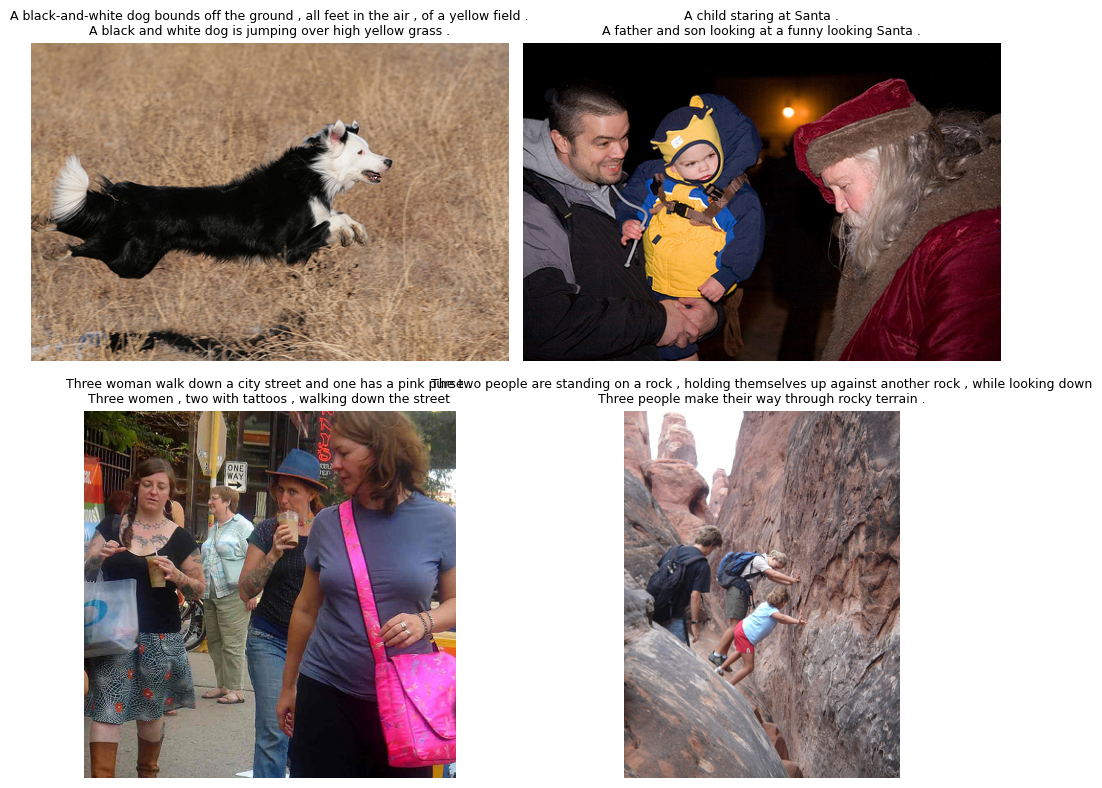

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
example_images = annotations_df.drop_duplicates("image_id").sample(4, random_state=SEED)
for ax, (_, row) in zip(axes.flat, example_images.iterrows()):
    ax.imshow(Image.open(row["image_path"]).convert("RGB"))
    ax.axis("off")
    refs = reference_captions[row["image_id"]][:2]
    ax.set_title("\n".join(refs), fontsize=9)
fig.tight_layout()
plt.show()

## 4 Preprocessing, Vocabulary und DataModule

Train-Transforms enthalten Augmentierung, damit das Modell nicht nur exakt gesehene Bildvarianten lernt. Val/Test-Transforms sind deterministisch, damit Validierungswerte reproduzierbar bleiben. `RandomRotation` ergänzt kleine Perspektiv- und Ausrichtungsvariation. `<pad>` wird im Loss ignoriert, sonst würden kürzere Captions durch Padding künstlich bestraft.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
SPECIAL_TOKENS = ["<pad>", "<start>", "<end>", "<unk>"]


def build_train_transforms(image_size: int) -> T.Compose:
    return T.Compose([
        T.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=8),
        T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def build_eval_transforms(image_size: int) -> T.Compose:
    # remark: keep train and validation transforms separate to avoid random validation results.
    return T.Compose([
        T.Resize(image_size + 32),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


class Vocabulary:
    def __init__(self, min_freq: int = MIN_FREQ):
        self.min_freq = min_freq
        self.token_to_idx: dict[str, int] = {}
        self.idx_to_token: list[str] = []
        self.counter: Counter[str] = Counter()

    def fit(self, captions: list[str]) -> None:
        self.counter = Counter(token for caption in captions for token in tokenize_caption(caption))
        kept_tokens = sorted(token for token, count in self.counter.items() if count >= self.min_freq)
        self.idx_to_token = SPECIAL_TOKENS + kept_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    @property
    def pad_idx(self) -> int:
        return self.token_to_idx["<pad>"]

    @property
    def start_idx(self) -> int:
        return self.token_to_idx["<start>"]

    @property
    def end_idx(self) -> int:
        return self.token_to_idx["<end>"]

    @property
    def unk_idx(self) -> int:
        return self.token_to_idx["<unk>"]

    def __len__(self) -> int:
        return len(self.idx_to_token)

    def encode(self, caption: str, add_special_tokens: bool = True, max_len: Optional[int] = None) -> list[int]:
        tokens = tokenize_caption(caption)
        if max_len is not None:
            special_space = 2 if add_special_tokens else 0
            tokens = tokens[: max(0, max_len - special_space)]
        ids = [self.token_to_idx.get(token, self.unk_idx) for token in tokens]
        return [self.start_idx] + ids + [self.end_idx] if add_special_tokens else ids

    def decode(self, token_ids: Union[list[int], torch.Tensor], skip_special_tokens: bool = True) -> str:
        if isinstance(token_ids, torch.Tensor):
            token_ids = token_ids.detach().cpu().tolist()
        hidden = {"<pad>", "<start>", "<end>"}
        tokens = []
        for idx in token_ids:
            idx = int(idx)
            token = self.idx_to_token[idx] if 0 <= idx < len(self.idx_to_token) else "<unk>"
            if skip_special_tokens and token in hidden:
                continue
            tokens.append(token)
        return " ".join(tokens)

In [6]:
class Flickr8kCaptionDataset(Dataset):
    def __init__(self, annotations: pd.DataFrame, vocab: Vocabulary, transform: Optional[Any], max_caption_len: int):
        self.annotations = annotations.reset_index(drop=True).copy()
        self.vocab = vocab
        self.transform = transform
        self.max_caption_len = max_caption_len

    def __len__(self) -> int:
        return len(self.annotations)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        row = self.annotations.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        caption_ids = self.vocab.encode(row["caption"], add_special_tokens=True, max_len=self.max_caption_len)
        return {
            "image": image,
            "caption_ids": torch.tensor(caption_ids, dtype=torch.long),
            "image_id": row["image_id"],
            "raw_caption": row["caption"],
        }


def make_caption_collate_fn(pad_idx: int):
    def collate_fn(batch: list[dict[str, Any]]) -> dict[str, Any]:
        images = torch.stack([item["image"] for item in batch])
        sequences = [item["caption_ids"] for item in batch]
        input_ids = pad_sequence([seq[:-1] for seq in sequences], batch_first=True, padding_value=pad_idx)
        target_ids = pad_sequence([seq[1:] for seq in sequences], batch_first=True, padding_value=pad_idx)
        lengths = torch.tensor([len(seq) - 1 for seq in sequences], dtype=torch.long)
        return {
            "images": images,
            "input_ids": input_ids,
            "target_ids": target_ids,
            "lengths": lengths,
            "image_ids": [item["image_id"] for item in batch],
            "raw_captions": [item["raw_caption"] for item in batch],
        }
    return collate_fn


class Flickr8kDataModule(L.LightningDataModule):
    def __init__(self, annotations: pd.DataFrame, batch_size: int = BATCH_SIZE, num_workers: int = NUM_WORKERS):
        super().__init__()
        self.annotations = annotations
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.reference_captions = annotations.groupby("image_id")["caption"].apply(list).to_dict()
        self.vocab: Optional[Vocabulary] = None

    def setup(self, stage: Optional[str] = None) -> None:
        train_df = self.annotations[self.annotations["split"] == "train"].reset_index(drop=True)
        val_df = self.annotations[self.annotations["split"] == "val"].reset_index(drop=True)
        test_df = self.annotations[self.annotations["split"] == "test"].reset_index(drop=True)
        self.vocab = Vocabulary(min_freq=MIN_FREQ)
        self.vocab.fit(train_df["caption"].tolist())
        self.train_dataset = Flickr8kCaptionDataset(train_df, self.vocab, build_train_transforms(IMAGE_SIZE), MAX_CAPTION_LEN)
        self.val_dataset = Flickr8kCaptionDataset(val_df, self.vocab, build_eval_transforms(IMAGE_SIZE), MAX_CAPTION_LEN)
        self.test_dataset = Flickr8kCaptionDataset(test_df, self.vocab, build_eval_transforms(IMAGE_SIZE), MAX_CAPTION_LEN)

    def _loader(self, dataset: Dataset, shuffle: bool) -> DataLoader:
        if self.vocab is None:
            raise RuntimeError("Call setup() before requesting dataloaders.")
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=self.num_workers,
            pin_memory=False,
            persistent_workers=self.num_workers > 0,
            collate_fn=make_caption_collate_fn(self.vocab.pad_idx),
        )

    def train_dataloader(self) -> DataLoader:
        return self._loader(self.train_dataset, shuffle=True)

    def val_dataloader(self) -> DataLoader:
        return self._loader(self.val_dataset, shuffle=False)

    def test_dataloader(self) -> DataLoader:
        return self._loader(self.test_dataset, shuffle=False)


dm = Flickr8kDataModule(annotations_df)
dm.setup()
batch = next(iter(dm.train_dataloader()))
print("images:", tuple(batch["images"].shape))
print("input_ids:", tuple(batch["input_ids"].shape))
print("target_ids:", tuple(batch["target_ids"].shape))
print("vocab size:", len(dm.vocab))

images: (32, 3, 224, 224)
input_ids: (32, 18)
target_ids: (32, 18)
vocab size: 2655


## 5 Modell 1: CNN-LSTM-Baseline ohne Attention

Die finale Baseline ist die korrigierte Image-Token-Variante. Während der Entwicklung wurde eine reine `h0/c0`-Baseline verworfen, weil der Overfitting-Test zeigte, dass Greedy-Decoding die Bildkonditionierung schlecht hielt. Deshalb nutzt die finale Baseline den globalen ResNet18-Bildvektor doppelt: zur Initialisierung von `h0/c0` und zusätzlich als initiales Decoder-Token.

In [7]:
def get_resnet_weights(encoder_name: str, pretrained: bool):
    # remark: avoid implicit downloads; use cached ImageNet weights if present, otherwise fall back clearly.
    if not pretrained:
        return None
    torch_home = Path(os.environ["TORCH_HOME"])
    if encoder_name == "resnet18":
        cache_file = torch_home / "hub" / "checkpoints" / "resnet18-f37072fd.pth"
        if cache_file.exists():
            return tv_models.ResNet18_Weights.DEFAULT
    if encoder_name == "resnet50":
        cache_file = torch_home / "hub" / "checkpoints" / "resnet50-0676ba61.pth"
        if cache_file.exists():
            return tv_models.ResNet50_Weights.DEFAULT
    print(f"Cached weights for {encoder_name} not found; using random initialization to avoid automatic download.")
    return None


class CNNEncoderGlobal(nn.Module):
    RESNET_DIMS = {"resnet18": 512, "resnet50": 2048}

    def __init__(self, encoder_name: str = ENCODER_NAME, pretrained: bool = PRETRAINED_ENCODER, freeze_encoder: bool = FREEZE_ENCODER, output_dim: int = HIDDEN_DIM):
        super().__init__()
        if encoder_name == "resnet18":
            backbone = tv_models.resnet18(weights=get_resnet_weights(encoder_name, pretrained))
        elif encoder_name == "resnet50":
            backbone = tv_models.resnet50(weights=get_resnet_weights(encoder_name, pretrained))
        else:
            raise ValueError(f"Unsupported encoder_name: {encoder_name}")
        feature_dim = backbone.fc.in_features
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.projection = nn.Sequential(nn.Linear(feature_dim, output_dim), nn.ReLU(inplace=True))
        if freeze_encoder:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(images).flatten(1)
        return self.projection(features)


class LSTMCaptionDecoderImageToken(nn.Module):
    def __init__(self, vocab_size: int, pad_idx: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=pad_idx)
        self.image_to_embed = nn.Linear(HIDDEN_DIM, EMBED_DIM)
        self.hidden_init = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.cell_init = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.output = nn.Linear(HIDDEN_DIM, vocab_size)
        self.dropout = nn.Dropout(DECODER_DROPOUT)

    def _init_state(self, image_features: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h0 = self.hidden_init(image_features).unsqueeze(0)
        c0 = self.cell_init(image_features).unsqueeze(0)
        return h0, c0

    def forward(self, image_features: torch.Tensor, input_ids: torch.Tensor) -> torch.Tensor:
        image_embedding = self.dropout(torch.tanh(self.image_to_embed(image_features))).unsqueeze(1)
        word_embeddings = self.dropout(self.embedding(input_ids[:, 1:]))
        decoder_inputs = torch.cat([image_embedding, word_embeddings], dim=1)
        outputs, _ = self.lstm(decoder_inputs, self._init_state(image_features))
        return self.output(outputs)

    def first_step(self, image_features: torch.Tensor):
        image_embedding = torch.tanh(self.image_to_embed(image_features)).unsqueeze(1)
        outputs, state = self.lstm(image_embedding, self._init_state(image_features))
        return self.output(outputs[:, -1]), state

    def next_step(self, token_ids: torch.Tensor, state):
        word_embedding = self.embedding(token_ids).unsqueeze(1)
        outputs, state = self.lstm(word_embedding, state)
        return self.output(outputs[:, -1]), state


class BaselineCaptioningModule(L.LightningModule):
    def __init__(self, vocab_size: int, pad_idx: int, start_idx: int, end_idx: int):
        super().__init__()
        self.save_hyperparameters()
        self.vocab_size = vocab_size
        self.pad_idx = pad_idx
        self.start_idx = start_idx
        self.end_idx = end_idx
        self.encoder = CNNEncoderGlobal()
        self.decoder = LSTMCaptionDecoderImageToken(vocab_size=vocab_size, pad_idx=pad_idx)
        # remark: the padding index is ignored by the loss, otherwise shorter captions would be penalized.
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_idx)

    def forward(self, images: torch.Tensor, input_ids: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(images), input_ids)

    def _compute_loss(self, batch: dict[str, Any]) -> torch.Tensor:
        logits = self(batch["images"], batch["input_ids"])
        return self.loss_fn(logits.reshape(-1, self.vocab_size), batch["target_ids"].reshape(-1))

    def training_step(self, batch: dict[str, Any], batch_idx: int) -> torch.Tensor:
        loss = self._compute_loss(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch["images"].size(0))
        return loss

    def validation_step(self, batch: dict[str, Any], batch_idx: int) -> torch.Tensor:
        loss = self._compute_loss(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch["images"].size(0))
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW([p for p in self.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len: int = MAX_DECODE_LEN) -> torch.Tensor:
        # remark: greedy decoding is used for both models so the comparison is consistent.
        was_training = self.training
        self.eval()
        image_features = self.encoder(images)
        logits, state = self.decoder.first_step(image_features)
        next_token = logits.argmax(dim=-1)
        generated = [torch.full_like(next_token, self.start_idx), next_token]
        finished = next_token.eq(self.end_idx)
        for _ in range(max_len - 1):
            logits, state = self.decoder.next_step(next_token, state)
            next_token = logits.argmax(dim=-1)
            generated.append(next_token)
            finished |= next_token.eq(self.end_idx)
            if torch.all(finished):
                break
        if was_training:
            self.train()
        return torch.stack(generated, dim=1)

## 6 Modell 2: CNN-LSTM mit Soft-Attention

Das Attention-Modell nutzt die räumliche ResNet18-Feature-Map statt nur eines globalen Bildvektors. Die additive Soft-Attention gewichtet pro Decoder-Schritt die 7x7 Bildregionen. Hyperparameter bleiben möglichst vergleichbar zur Baseline.

In [8]:
class CNNEncoderSpatial(nn.Module):
    RESNET_DIMS = {"resnet18": 512, "resnet50": 2048}

    def __init__(self, encoder_name: str = ENCODER_NAME, pretrained: bool = PRETRAINED_ENCODER, freeze_encoder: bool = FREEZE_ENCODER):
        super().__init__()
        if encoder_name == "resnet18":
            backbone = tv_models.resnet18(weights=get_resnet_weights(encoder_name, pretrained))
        elif encoder_name == "resnet50":
            backbone = tv_models.resnet50(weights=get_resnet_weights(encoder_name, pretrained))
        else:
            raise ValueError(f"Unsupported encoder_name: {encoder_name}")
        self.feature_dim = backbone.fc.in_features
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-2])
        if freeze_encoder:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        feature_map = self.feature_extractor(images)
        batch_size, feature_dim, height, width = feature_map.shape
        return feature_map.permute(0, 2, 3, 1).reshape(batch_size, height * width, feature_dim)


class AdditiveAttention(nn.Module):
    def __init__(self, feature_dim: int = HIDDEN_DIM):
        super().__init__()
        self.feature_projection = nn.Linear(feature_dim, ATTENTION_DIM)
        self.hidden_projection = nn.Linear(HIDDEN_DIM, ATTENTION_DIM)
        self.score_projection = nn.Linear(ATTENTION_DIM, 1)

    def forward(self, spatial_features: torch.Tensor, hidden_state: torch.Tensor):
        projected_features = self.feature_projection(spatial_features)
        projected_hidden = self.hidden_projection(hidden_state).unsqueeze(1)
        scores = self.score_projection(torch.tanh(projected_features + projected_hidden)).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), spatial_features).squeeze(1)
        return context, weights


class AttentionLSTMDecoder(nn.Module):
    def __init__(self, vocab_size: int, pad_idx: int, feature_dim: int = HIDDEN_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=pad_idx)
        self.attention = AdditiveAttention(feature_dim=feature_dim)
        self.hidden_init = nn.Linear(feature_dim, HIDDEN_DIM)
        self.cell_init = nn.Linear(feature_dim, HIDDEN_DIM)
        self.lstm_cell = nn.LSTMCell(EMBED_DIM + feature_dim, HIDDEN_DIM)
        self.output = nn.Linear(HIDDEN_DIM, vocab_size)
        self.dropout = nn.Dropout(DECODER_DROPOUT)

    def init_state(self, spatial_features: torch.Tensor):
        mean_features = spatial_features.mean(dim=1)
        return torch.tanh(self.hidden_init(mean_features)), torch.tanh(self.cell_init(mean_features))

    def step(self, token_ids: torch.Tensor, spatial_features: torch.Tensor, h: torch.Tensor, c: torch.Tensor):
        context, weights = self.attention(spatial_features, h)
        embeddings = self.dropout(self.embedding(token_ids))
        h, c = self.lstm_cell(torch.cat([embeddings, context], dim=1), (h, c))
        logits = self.output(self.dropout(h))
        return logits, weights, h, c

    def forward(self, spatial_features: torch.Tensor, input_ids: torch.Tensor):
        h, c = self.init_state(spatial_features)
        logits_steps, attention_steps = [], []
        for t in range(input_ids.size(1)):
            logits, weights, h, c = self.step(input_ids[:, t], spatial_features, h, c)
            logits_steps.append(logits)
            attention_steps.append(weights)
        return torch.stack(logits_steps, dim=1), torch.stack(attention_steps, dim=1)


class AttentionCaptioningModule(L.LightningModule):
    def __init__(self, vocab_size: int, pad_idx: int, start_idx: int, end_idx: int):
        super().__init__()
        self.save_hyperparameters()
        self.vocab_size = vocab_size
        self.pad_idx = pad_idx
        self.start_idx = start_idx
        self.end_idx = end_idx
        self.encoder = CNNEncoderSpatial()
        self.decoder = AttentionLSTMDecoder(vocab_size=vocab_size, pad_idx=pad_idx)
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_idx)

    def forward(self, images: torch.Tensor, input_ids: torch.Tensor):
        return self.decoder(self.encoder(images), input_ids)

    def _compute_loss(self, batch: dict[str, Any]) -> torch.Tensor:
        logits, _ = self(batch["images"], batch["input_ids"])
        return self.loss_fn(logits.reshape(-1, self.vocab_size), batch["target_ids"].reshape(-1))

    def training_step(self, batch: dict[str, Any], batch_idx: int) -> torch.Tensor:
        loss = self._compute_loss(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch["images"].size(0))
        return loss

    def validation_step(self, batch: dict[str, Any], batch_idx: int) -> torch.Tensor:
        loss = self._compute_loss(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch["images"].size(0))
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW([p for p in self.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len: int = MAX_DECODE_LEN, return_attention: bool = False):
        was_training = self.training
        self.eval()
        spatial_features = self.encoder(images)
        h, c = self.decoder.init_state(spatial_features)
        current = torch.full((images.size(0),), self.start_idx, dtype=torch.long, device=images.device)
        generated = [current]
        attention_steps = []
        finished = torch.zeros(images.size(0), dtype=torch.bool, device=images.device)
        for _ in range(max_len):
            logits, weights, h, c = self.decoder.step(current, spatial_features, h, c)
            current = logits.argmax(dim=-1)
            generated.append(current)
            attention_steps.append(weights)
            finished |= current.eq(self.end_idx)
            if torch.all(finished):
                break
        tokens = torch.stack(generated, dim=1)
        attentions = torch.stack(attention_steps, dim=1) if attention_steps else torch.empty(images.size(0), 0, spatial_features.size(1), device=images.device)
        if was_training:
            self.train()
        return (tokens, attentions) if return_attention else tokens

## 7 Training- und Evaluationsfunktionen

Die Funktionen sind absichtlich klein gehalten. Es gibt keine Experiment-Engine, sondern nur wiederverwendbare Bausteine für Overfitting-Test, Training, BLEU, qualitative Beispiele und Ergebnisdateien.

In [9]:
class LossHistoryCallback(Callback):
    def __init__(self):
        super().__init__()
        self.train_loss: list[float] = []
        self.val_loss: list[float] = []

    def on_train_epoch_end(self, trainer, pl_module) -> None:
        value = trainer.callback_metrics.get("train_loss")
        if value is not None:
            self.train_loss.append(float(value.detach().cpu()))

    def on_validation_epoch_end(self, trainer, pl_module) -> None:
        value = trainer.callback_metrics.get("val_loss")
        if value is not None and not trainer.sanity_checking:
            self.val_loss.append(float(value.detach().cpu()))


class FixedCaptionBatchDataset(Dataset):
    def __init__(self, batch: dict[str, Any]):
        self.images = batch["images"].detach().cpu()
        self.image_ids = list(batch["image_ids"])
        self.raw_captions = list(batch["raw_captions"])
        self.caption_ids = []
        for input_row, target_row, length in zip(batch["input_ids"], batch["target_ids"], batch["lengths"]):
            length = int(length.item())
            sequence = torch.cat([input_row[:length], target_row[length - 1:length]]).detach().cpu()
            self.caption_ids.append(sequence)

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        return {"image": self.images[idx].clone(), "caption_ids": self.caption_ids[idx].clone(), "image_id": self.image_ids[idx], "raw_caption": self.raw_captions[idx]}


def run_overfit_test(model: L.LightningModule, fixed_batch: dict[str, Any], vocab: Vocabulary, epochs: int = OVERFIT_EPOCHS):
    fixed_dataset = FixedCaptionBatchDataset(fixed_batch)
    fixed_loader = DataLoader(fixed_dataset, batch_size=len(fixed_dataset), shuffle=False, num_workers=0, collate_fn=make_caption_collate_fn(vocab.pad_idx))
    history = LossHistoryCallback()
    with torch.no_grad():
        before = model.generate(fixed_batch["images"][:4], max_len=MAX_DECODE_LEN).cpu()
    trainer = L.Trainer(
        max_epochs=epochs,
        accelerator="mps" if torch.backends.mps.is_available() else "cpu",
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        enable_progress_bar=False,
        deterministic=True,
        limit_train_batches=1,
        callbacks=[history],
    )
    trainer.fit(model, train_dataloaders=fixed_loader)
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        after = model.generate(fixed_batch["images"][:4].to(device), max_len=MAX_DECODE_LEN).cpu()
    rows = []
    for i in range(4):
        rows.append({
            "image_id": fixed_batch["image_ids"][i],
            "reference_caption": fixed_batch["raw_captions"][i],
            "generated_before": vocab.decode(before[i]),
            "generated_after": vocab.decode(after[i]),
        })
    return {"train_loss": history.train_loss}, pd.DataFrame(rows), model


def train_model(model: L.LightningModule, datamodule: Flickr8kDataModule, run_id: str, checkpoint_dir: Path):
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    history = LossHistoryCallback()
    checkpoint = ModelCheckpoint(dirpath=checkpoint_dir, filename=f"{run_id}-{{epoch:02d}}-{{val_loss:.3f}}", monitor="val_loss", mode="min", save_top_k=1)
    start = time.time()
    trainer = L.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="mps" if torch.backends.mps.is_available() else "cpu",
        devices=1,
        logger=False,
        enable_checkpointing=True,
        callbacks=[checkpoint, history],
        deterministic=True,
        precision="32-true",
    )
    trainer.fit(model, train_dataloaders=datamodule.train_dataloader(), val_dataloaders=datamodule.val_dataloader())
    runtime_sec = time.time() - start
    return {"train_loss": history.train_loss, "val_loss": history.val_loss}, checkpoint.best_model_path, float(checkpoint.best_model_score.detach().cpu()), runtime_sec


def evaluate_greedy_bleu(model: L.LightningModule, datamodule: Flickr8kDataModule, num_images: Optional[int] = None) -> tuple[pd.DataFrame, dict[str, float]]:
    model.eval()
    device = next(model.parameters()).device
    val_unique = datamodule.annotations[datamodule.annotations["split"] == "val"].drop_duplicates("image_id").reset_index(drop=True)
    if num_images is not None:
        val_unique = val_unique.head(num_images)
    eval_dataset = Flickr8kCaptionDataset(val_unique, datamodule.vocab, build_eval_transforms(IMAGE_SIZE), MAX_CAPTION_LEN)
    eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=make_caption_collate_fn(datamodule.vocab.pad_idx))
    smoothing = SmoothingFunction().method1
    all_references, all_hypotheses, rows = [], [], []
    with torch.no_grad():
        for batch in eval_loader:
            images = batch["images"].to(device)
            generated = model.generate(images, max_len=MAX_DECODE_LEN)
            if isinstance(generated, tuple):
                generated = generated[0]
            generated = generated.cpu()
            for image_id, token_ids in zip(batch["image_ids"], generated):
                caption = datamodule.vocab.decode(token_ids)
                refs = datamodule.reference_captions[image_id]
                all_references.append([tokenize_caption(ref) for ref in refs])
                hyp = tokenize_caption(caption) or ["<empty>"]
                all_hypotheses.append(hyp)
                rows.append({"image_id": image_id, "generated_caption": caption, "references": refs})
    scores = {
        "BLEU-1": corpus_bleu(all_references, all_hypotheses, weights=(1.0, 0, 0, 0), smoothing_function=smoothing),
        "BLEU-2": corpus_bleu(all_references, all_hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing),
        "BLEU-3": corpus_bleu(all_references, all_hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothing),
        "BLEU-4": corpus_bleu(all_references, all_hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing),
    }
    return pd.DataFrame(rows), scores


def save_run_outputs(run_id: str, payload: dict[str, Any], examples: pd.DataFrame) -> None:
    outputs_dir = PROJECT_ROOT / "outputs"
    outputs_dir.mkdir(parents=True, exist_ok=True)
    save_json(payload, outputs_dir / f"{run_id}_metrics.json")
    save_json(examples.head(8).to_dict(orient="records"), outputs_dir / f"{run_id}_examples.json")


def append_results_summary(rows: list[dict[str, Any]]) -> pd.DataFrame:
    summary = pd.DataFrame(rows)
    summary.to_csv(PROJECT_ROOT / "outputs" / "results_summary.csv", index=False)
    return summary

## 8 Overfitting-Tests

Beide Modelle verwenden exakt denselben fixen Mini-Batch. Der Overfit-Dataloader shuffelt nicht; bei jedem Update sieht das Modell dieselben Bilder und Captions. Der Test prüft, ob Modell, Loss und Datenfluss grundsätzlich lernen können. Er beweist keine Generalisierung auf neue Bilder.

Einstellungen für beide Modelle: ResNet18, frozen Encoder, Batch Size 32, gleiche Learning Rate, 100 Overfit-Epochen, kein Logger, kein Checkpointing, kein EarlyStopping und Greedy-Decoding.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.


/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=100` reached.


...

TPU available: False, using: 0 TPU cores


`Trainer(limit_train_batches=1)` was configured so 1 batch per epoch will be used.


`Trainer.fit` stopped: `max_epochs=100` reached.


,image_id,reference_caption,generated_before,generated_after
0,3358621566_12bac2e9d2.jpg,There are two oriental people in robes standin...,preparing sheet sheet referee beside crosses s...,there are two oriental people in robes standin...
1,2885387575_9127ea10f1.jpg,A gray dog chases a blue soccer ball on the gr...,body body bouncy horizontal cobblestone boards...,a gray dog chases a blue soccer ball on the grass
2,1408958345_68eea9a4e4.jpg,A little girl in a flower swimsuit running acr...,uniform handle mug marked pumpkins view dimly ...,a little girl in a flower swimsuit running acr...
3,310260324_7f941814bc.jpg,A group of men lift their arms to signal while...,body body bouncy horizontal cobblestone boards...,a group of men lift their arms to <unk> while ...


,image_id,reference_caption,generated_before,generated_after
0,3358621566_12bac2e9d2.jpg,There are two oriental people in robes standin...,pierced kissing place little little playing mi...,there are two oriental people in robes standin...
1,2885387575_9127ea10f1.jpg,A gray dog chases a blue soccer ball on the gr...,waterfalls riders riders hang hang hang hang p...,a gray dog chases a blue soccer ball on the grass
2,1408958345_68eea9a4e4.jpg,A little girl in a flower swimsuit running acr...,one one men couch couch couch couch couch couc...,a little girl in a flower swimsuit running acr...
3,310260324_7f941814bc.jpg,A group of men lift their arms to signal while...,breaking sumo labrador pizza purses guide purs...,a group of men lift their arms to <unk> while ...


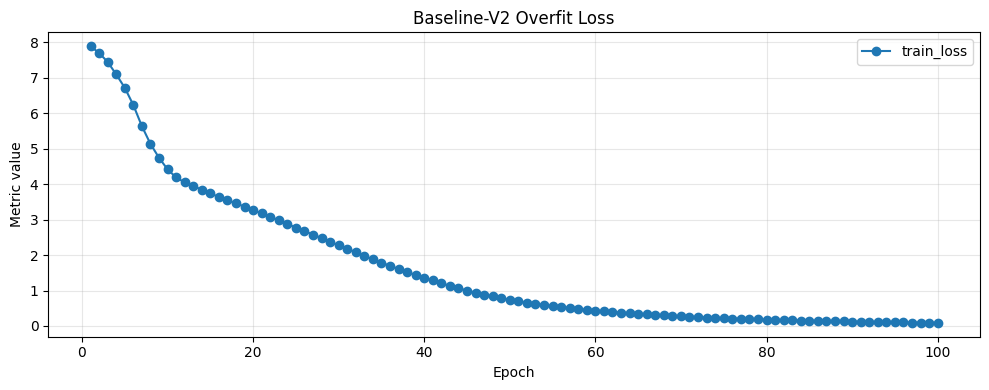

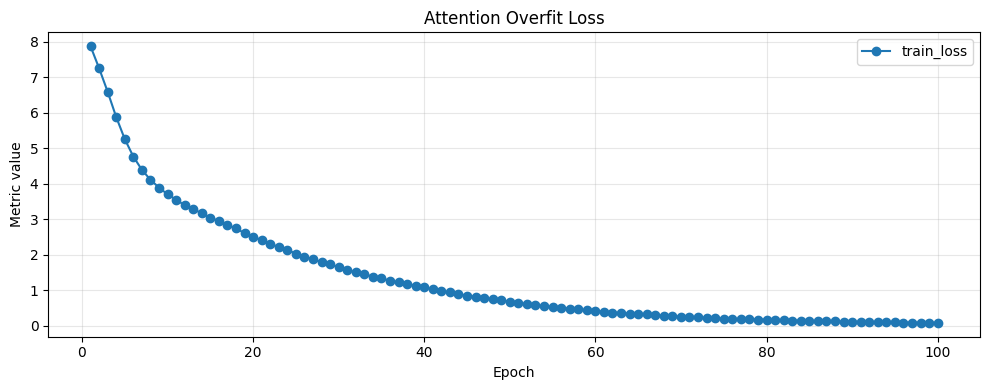

Baseline-V2 loss: 7.895 -> 0.087
Attention loss:   7.878 -> 0.086
Saved: /Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/outputs/clean_baseline_overfit_results.json
Saved: /Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/outputs/clean_attention_overfit_results.json


In [10]:
if RUN_OVERFIT_TESTS:
    fixed_batch = next(iter(dm.train_dataloader()))
    baseline_overfit_model = BaselineCaptioningModule(len(dm.vocab), dm.vocab.pad_idx, dm.vocab.start_idx, dm.vocab.end_idx)
    attention_overfit_model = AttentionCaptioningModule(len(dm.vocab), dm.vocab.pad_idx, dm.vocab.start_idx, dm.vocab.end_idx)

    baseline_overfit_history, baseline_overfit_examples, _ = run_overfit_test(baseline_overfit_model, fixed_batch, dm.vocab)
    attention_overfit_history, attention_overfit_examples, _ = run_overfit_test(attention_overfit_model, fixed_batch, dm.vocab)

    def overfit_payload(model_name: str, history: dict[str, list[float]], examples: pd.DataFrame) -> dict[str, Any]:
        losses = history["train_loss"]
        return {
            "model": model_name,
            "settings": {
                "encoder": ENCODER_NAME,
                "freeze_encoder": FREEZE_ENCODER,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "overfit_epochs": OVERFIT_EPOCHS,
                "checkpointing": False,
                "logger": False,
                "early_stopping": False,
                "decoding": "greedy",
            },
            "start_loss": float(losses[0]) if losses else None,
            "end_loss": float(losses[-1]) if losses else None,
            "loss_history": [float(v) for v in losses],
            "examples": examples.to_dict(orient="records"),
        }

    baseline_overfit_payload = overfit_payload("baseline_v2", baseline_overfit_history, baseline_overfit_examples)
    attention_overfit_payload = overfit_payload("attention", attention_overfit_history, attention_overfit_examples)
    save_json(baseline_overfit_payload, PROJECT_ROOT / "outputs" / "clean_baseline_overfit_results.json")
    save_json(attention_overfit_payload, PROJECT_ROOT / "outputs" / "clean_attention_overfit_results.json")

    display(baseline_overfit_examples)
    display(attention_overfit_examples)

    plot_training_curves(baseline_overfit_history, ["train_loss"], "Baseline-V2 Overfit Loss")
    plt.show()
    plot_training_curves(attention_overfit_history, ["train_loss"], "Attention Overfit Loss")
    plt.show()

    print(f"Baseline-V2 loss: {baseline_overfit_payload['start_loss']:.3f} -> {baseline_overfit_payload['end_loss']:.3f}")
    print(f"Attention loss:   {attention_overfit_payload['start_loss']:.3f} -> {attention_overfit_payload['end_loss']:.3f}")
    print("Saved:", PROJECT_ROOT / "outputs" / "clean_baseline_overfit_results.json")
    print("Saved:", PROJECT_ROOT / "outputs" / "clean_attention_overfit_results.json")
else:
    print("Overfitting tests are defined but skipped. Set RUN_OVERFIT_TESTS=True to run them.")


> **Kurzinterpretation Overfitting-Test**
>
> Beide Modelle werden auf demselben fixen Mini-Batch geprüft. Ein klar fallender Loss und bessere Greedy-Captions zeigen, dass Modell, Loss und Datenfluss technisch funktionieren und der Batch memorisiert werden kann. Das ist kein Nachweis für Generalisierung auf neue Bilder; dafür braucht es die späteren Full-Train/Val-Runs mit Val-Loss, BLEU und qualitativen Beispielen.


## 9 Haupttraining: Baseline vs. Attention

Die finalen Runs sollen auf dem vollen Train- und Val-Dataloader laufen. Beide Modelle verwenden ResNet18, frozen Encoder, gleiche Batch Size, gleiche Learning Rate und Greedy-Decoding. `RUN_FULL_TRAINING=False` verhindert automatisches Training beim Öffnen des Notebooks. Wenn keine passenden Checkpoints vorhanden sind, wird klar gemeldet, dass die Full-Runs noch ausstehen.

In [11]:
BASELINE_RUN_ID = "baseline_v2_resnet18_frozen_20ep_full"
ATTENTION_RUN_ID = "attention_resnet18_frozen_20ep_full"


def latest_checkpoint(checkpoint_dir: Path) -> Optional[Path]:
    candidates = sorted(checkpoint_dir.glob("*.ckpt"), key=lambda p: p.stat().st_mtime)
    return candidates[-1] if candidates else None


full_run_results = []
trained_models = {}

if RUN_FULL_TRAINING:
    baseline_model = BaselineCaptioningModule(len(dm.vocab), dm.vocab.pad_idx, dm.vocab.start_idx, dm.vocab.end_idx)
    baseline_history, baseline_ckpt, baseline_best_val, baseline_runtime = train_model(baseline_model, dm, BASELINE_RUN_ID, PROJECT_ROOT / "checkpoints" / "baseline_v2")
    attention_model = AttentionCaptioningModule(len(dm.vocab), dm.vocab.pad_idx, dm.vocab.start_idx, dm.vocab.end_idx)
    attention_history, attention_ckpt, attention_best_val, attention_runtime = train_model(attention_model, dm, ATTENTION_RUN_ID, PROJECT_ROOT / "checkpoints" / "attention")
    print("Baseline checkpoint:", baseline_ckpt)
    print("Attention checkpoint:", attention_ckpt)
else:
    print("Full training skipped. Set RUN_FULL_TRAINING=True for the final 20-epoch runs.")
    for run_id, model_class, ckpt_dir in [
        (BASELINE_RUN_ID, BaselineCaptioningModule, PROJECT_ROOT / "checkpoints" / "baseline_v2"),
        (ATTENTION_RUN_ID, AttentionCaptioningModule, PROJECT_ROOT / "checkpoints" / "attention"),
    ]:
        ckpt = latest_checkpoint(ckpt_dir)
        if ckpt is None:
            print(f"No checkpoint found for {run_id} in {ckpt_dir}.")
        else:
            model = model_class.load_from_checkpoint(ckpt, vocab_size=len(dm.vocab), pad_idx=dm.vocab.pad_idx, start_idx=dm.vocab.start_idx, end_idx=dm.vocab.end_idx, map_location="cpu")
            trained_models[run_id] = model
            print(f"Loaded {run_id}: {ckpt}")

Full training skipped. Set RUN_FULL_TRAINING=True for the final 20-epoch runs.
No checkpoint found for baseline_v2_resnet18_frozen_20ep_full in /Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/checkpoints/baseline_v2.
No checkpoint found for attention_resnet18_frozen_20ep_full in /Users/stefanbinkert/Documents/FHNW_DS/VDL/mc_vdl/VDL_MC/checkpoints/attention.


## 10 Evaluation und Modellvergleich

Verglichen werden die beiden Full-Run-IDs. BLEU ist n-Gram-basiert und misst semantische Caption-Qualität nur begrenzt; deshalb werden Val-Loss, BLEU, qualitative Beispiele und bei Attention zusätzlich Heatmaps gemeinsam betrachtet.

In [12]:
evaluation_rows = []
for run_id, model in trained_models.items():
    model = model.to(DEVICE)
    examples, bleu = evaluate_greedy_bleu(model, dm)
    trainable_params = count_parameters(model)
    metrics_payload = {
        "run_id": run_id,
        "BLEU": bleu,
        "trainable_parameters": trainable_params,
        "config": {
            "encoder": ENCODER_NAME,
            "freeze_encoder": FREEZE_ENCODER,
            "epochs": MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "greedy_decoding": True,
        },
    }
    save_run_outputs(run_id, metrics_payload, examples)
    evaluation_rows.append({"run_id": run_id, "trainable_parameters": trainable_params, **bleu})

if evaluation_rows:
    comparison_table = append_results_summary(evaluation_rows)
    display(comparison_table)
else:
    print("No trained full-run checkpoints loaded yet; evaluation table will be created after training.")

No trained full-run checkpoints loaded yet; evaluation table will be created after training.


In [13]:
def show_attention_heatmaps(model: AttentionCaptioningModule, datamodule: Flickr8kDataModule, image_index: int = 0, max_tokens: int = 6) -> None:
    if not isinstance(model, AttentionCaptioningModule):
        print("Attention heatmaps are only available for the AttentionCaptioningModule.")
        return
    sample = datamodule.val_dataset[image_index]
    image = sample["image"].unsqueeze(0).to(next(model.parameters()).device)
    generated, weights = model.generate(image, return_attention=True)
    caption = datamodule.vocab.decode(generated[0].cpu())
    print("Generated:", caption)
    tokens = datamodule.vocab.decode(generated[0].cpu(), skip_special_tokens=False).split()[1:]
    grid = int(weights.shape[-1] ** 0.5)
    raw_image = Image.open(datamodule.val_dataset.annotations.iloc[image_index]["image_path"]).convert("RGB")
    for t, token in enumerate(tokens[:max_tokens]):
        if t >= weights.shape[1] or token in {"<pad>", "<start>"}:
            continue
        attention_map = weights[0, t].detach().cpu().reshape(grid, grid)
        fig = plot_attention_overlay(raw_image, attention_map, title=token)
        plt.show()


if ATTENTION_RUN_ID in trained_models:
    show_attention_heatmaps(trained_models[ATTENTION_RUN_ID].to(DEVICE), dm)
else:
    print("Attention heatmaps will be shown after the attention full-run checkpoint is available.")

Attention heatmaps will be shown after the attention full-run checkpoint is available.


## 11 Nächster Schritt: Optimierung des Siegers

Nach dem fairen Baseline-vs-Attention-Vergleich wird der Sieger anhand Val-Loss, BLEU und qualitativen Beispielen ausgewählt. Erst danach folgen Optimierungen: Optuna-Tuning, ResNet50 statt ResNet18, optionales Unfreezing später ResNet-Layer und Tuning von Learning Rate, Dropout, Weight Decay, Hidden- und Attention-Dimensionen.

## 12 Fazit / Key Takeaways

- Die Datenpipeline ist kompakt und reproduzierbar vorbereitet.
- Die finale Baseline nutzt Image-Token-Conditioning, weil die reine `h0/c0`-Variante in Greedy-Decoding problematisch war.
- Das Attention-Modell ergänzt räumliche Soft-Attention und ermöglicht Heatmaps.
- Overfitting-Tests prüfen nur technische Lernfähigkeit, nicht Generalisierung.
- Der faire Modellvergleich basiert auf den beiden Full-Runs `baseline_v2_resnet18_frozen_20ep_full` und `attention_resnet18_frozen_20ep_full`.
- Optimierung kommt erst nach diesem Vergleich.

## Technischer Smoke Check

Diese Zelle führt bewusst kein Training aus. Sie prüft nur, ob Imports, DataModule, ein Batch und Forward-Pässe beider Modelle funktionieren.

In [14]:
smoke_batch = next(iter(dm.train_dataloader()))
baseline_smoke = BaselineCaptioningModule(len(dm.vocab), dm.vocab.pad_idx, dm.vocab.start_idx, dm.vocab.end_idx)
attention_smoke = AttentionCaptioningModule(len(dm.vocab), dm.vocab.pad_idx, dm.vocab.start_idx, dm.vocab.end_idx)
baseline_smoke.eval()
attention_smoke.eval()
with torch.no_grad():
    baseline_logits = baseline_smoke(smoke_batch["images"], smoke_batch["input_ids"])
    attention_logits, attention_weights = attention_smoke(smoke_batch["images"], smoke_batch["input_ids"])

print("baseline logits:", tuple(baseline_logits.shape))
print("attention logits:", tuple(attention_logits.shape))
print("attention weights:", tuple(attention_weights.shape))
assert baseline_logits.shape[:2] == smoke_batch["input_ids"].shape
assert attention_logits.shape[:2] == smoke_batch["input_ids"].shape
assert baseline_logits.shape[-1] == len(dm.vocab)
assert attention_logits.shape[-1] == len(dm.vocab)
assert torch.allclose(attention_weights.sum(dim=-1), torch.ones_like(attention_weights.sum(dim=-1)), atol=1e-5)
print("Technical smoke checks passed.")

baseline logits: (32, 21, 2655)
attention logits: (32, 21, 2655)
attention weights: (32, 21, 49)
Technical smoke checks passed.
